### Contexto e Objetivo

Está sendo desenvolvido um modelo de classificação de dados em uma base de serviço para avaliar se um cliente irá continuar no serviço ou irá cancelá-lo. Essa analise poderá ser util para identificar as chances do cliente querer desistir do serviço que possui, e avaliar os fatores que podem afetar nessa decisão


Importação de Dependências

In [1]:
from functions import gini_coeficient, gmean_max
import pandas as pd
import numpy as np 

import seaborn as sns
import matplotlib.pyplot as plt 

from catboost import CatBoostClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

In [2]:
df_credit = pd.read_csv(r"..\\documents\\Credit_Card_Churn.csv")

# Análise Inicial da base de Crédito

In [3]:
# Não apresenta nenhum valor nulo

df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10000 non-null  int64  
 1   Attrition_Flag            10000 non-null  object 
 2   Customer_Age              10000 non-null  int64  
 3   Gender                    10000 non-null  object 
 4   Dependent_count           10000 non-null  int64  
 5   Education_Level           10000 non-null  object 
 6   Marital_Status            10000 non-null  object 
 7   Income_Category           10000 non-null  object 
 8   Card_Category             10000 non-null  object 
 9   Months_on_book            10000 non-null  int64  
 10  Total_Relationship_Count  10000 non-null  int64  
 11  Months_Inactive_12_mon    10000 non-null  int64  
 12  Contacts_Count_12_mon     10000 non-null  int64  
 13  Credit_Limit              10000 non-null  float64
 14  Total_R

Análise de valores únicos

In [4]:
for x in df_credit.columns:
    print(f'Coluna: {x}')
    print(np.sort(df_credit[x].unique()), "\n")
    

Coluna: CLIENTNUM
[100000000 100000001 100000002 ... 100009997 100009998 100009999] 

Coluna: Attrition_Flag
['Attrited Customer' 'Existing Customer'] 

Coluna: Customer_Age
[26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72] 

Coluna: Gender
['F' 'M'] 

Coluna: Dependent_count
[0 1 2 3 4 5] 

Coluna: Education_Level
['College' 'Doctorate' 'Graduate' 'High School' 'Post-Graduate'
 'Uneducated'] 

Coluna: Marital_Status
['Divorced' 'Married' 'Single'] 

Coluna: Income_Category
['$120K +' '$40K - $60K' '$60K - $80K' '$80K - $120K' 'Less than $40K'
 'Unknown'] 

Coluna: Card_Category
['Blue' 'Gold' 'Platinum' 'Silver'] 

Coluna: Months_on_book
[12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59
 60] 

Coluna: Total_Relationship_Count
[1 2 3 4 5 6] 

Coluna: Months_Inactive_12_mon
[0 1 2 3 4 5 6] 

Coluna: 

Avaliar se o dataset apresenta valores negativos

In [5]:
colunas_numericas = [c for c in df_credit.columns if df_credit[c].dtype != 'object']

print("Colunas com valores abaixo de 0:")

for c in colunas_numericas:
    if (df_credit[c] < 0).any():
        print(c)


Colunas com valores abaixo de 0:
Avg_Open_To_Buy


In [6]:
# Análise percentual de clientes que cancelaram o cartão de crédito

df_credit['Attrition_Flag'].value_counts(normalize=True)

Attrition_Flag
Existing Customer    0.85
Attrited Customer    0.15
Name: proportion, dtype: float64

In [7]:
# Análise percentual de clientes que cancelaram o cartão de crédito por tipo de cartão

df_credit.groupby("Card_Category")['Attrition_Flag'].value_counts(normalize=True)

Card_Category  Attrition_Flag   
Blue           Existing Customer    0.84
               Attrited Customer    0.16
Gold           Existing Customer    0.87
               Attrited Customer    0.13
Platinum       Existing Customer    0.90
               Attrited Customer    0.10
Silver         Existing Customer    0.86
               Attrited Customer    0.14
Name: proportion, dtype: float64

# Tratamento dos Dados

Nessa estapa está sendo adaptado as colunas em string para padrões numérico para avaliar o quanto elas se correlacionam entre si e então descartando as colunas que poderiam confundir o modelo

In [8]:
df_base_credit = df_credit.copy()

### Avaliação Ordinal Encoding

In [9]:
df_base_credit['Income_Category'].value_counts()

Income_Category
Unknown           1709
$120K +           1690
Less than $40K    1676
$60K - $80K       1659
$80K - $120K      1636
$40K - $60K       1630
Name: count, dtype: int64

Pelo fato do valor Unknown apresentar uma frequencia maior no Income_Category, ao opta-lo por substituí-lo
pela medianda iria criar uma quantidade artificial de uma faixa de renda aleatória, fazendo com que o modelo
perca a habilidade de encontrar padrões

In [10]:
# Mapeamento de Income Category
mapa_category = {
    "Less than $40K": 0, "$40K - $60K": 1, "$60K - $80K": 2, 
    "$80K - $120K": 3, "$120K +": 4, 'Unknown': -1
}
df_base_credit['Income_Category'] = df_base_credit['Income_Category'].map(mapa_category)


# Mapeamento de Education_Level
mapa_edu = {
    'Uneducated': 0, 'High School': 1, 'College': 2, 
    'Graduate': 3, 'Post-Graduate': 4, 'Doctorate': 5
}
df_base_credit['Education_Level'] = df_base_credit['Education_Level'].map(mapa_edu)

In [11]:
# 1. Definição do mapeamento (Lista de listas para o OrdinalEncoder)
#income_category_map = [["Less than $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +"]]

# 2. Tratamento inicial de 'Unknown' (substituido por nulo)
#df_base_credit['Income_Category'] = df_base_credit['Income_Category'].replace('Unknown', np.nan)

# 3. Configuração do Ordinal Encoder
# foi usado  handle_unknown='use_encoded_value' para evitar erros com valores inesperados
#ordinal_encoder = OrdinalEncoder(
  #  categories=income_category_map,
   # handle_unknown='use_encoded_value', 
    #unknown_value=np.nan
#)

# 4. Aplicação da Transformação Ordinal
#df_base_credit['Income_Category'] = ordinal_encoder.fit_transform(df_base_credit[['Income_Category']])
#df_base_credit['Income_Category'] = df_base_credit[['Income_Category']] + 1

# 5. Tratamento de Valores Ausentes
# foram substituidos valores nulos pela mediana dos valores mapeados
#imputer = SimpleImputer(strategy='median') 
#df_base_credit['Income_Category'] = imputer.fit_transform(df_base_credit[['Income_Category']])
#df_base_credit['Income_Category'] = df_base_credit['Income_Category'] + 1


Foi criado um arquivo adaptado do Credit_Card_Churn onde a coluna Income_Category foi adaptada para numérica, de modo a endenter melhor quais colunas estão prejudicando os modelos por meio da plataforma Orange

In [12]:
#df_base_credit.to_csv(r"..\\documents\\CREDIT_CARD_CHURN_ADAPTED.csv", index=False)

### Avaliação One-Hot Encoder

In [13]:
df_base_credit['Gender'] = df_base_credit['Gender'].map({'F': 0, 'M': 1})

colunas_converter = ['Marital_Status', 'Card_Category']

df_base_credit = pd.get_dummies(data=df_base_credit, columns=colunas_converter, drop_first=True, dtype=int)

In [14]:
#ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

#dados_encoder = ohe.fit_transform(df_base_credit[colunas_converter])
#df_encoder = pd.DataFrame(data=dados_encoder, columns=ohe.get_feature_names_out())

# União dos dados com os dataframes-One-Hot-Encoder
#df_base_credit = (pd.concat([df_base_credit, df_encoder], axis=1))
#df_base_credit = df_base_credit.drop(columns=colunas_converter)

### Criação de Novas Colunas

Para melhorar o poder preditivo em relação aos modelos foi optado em
incluir novas medidas e avaliar sua relação com a variável target

In [15]:
# 1) divisão do valor das transações pela quantidade de transações
df_base_credit['Avg_Trans'] = round(df_base_credit['Total_Trans_Amt'] / (df_base_credit['Total_Trans_Ct'] + 1e-5), 2)

# 2) Percentual de utilização do crédito efetivado
df_base_credit['Revolving_To_Limit_Credit'] = df_base_credit['Total_Revolving_Bal']/(df_base_credit['Credit_Limit'] + 1e-5)

# 3) Indicador de inatividades recentes
df_base_credit['Inactive_Contact_Score'] = df_base_credit['Contacts_Count_12_mon'] * df_base_credit['Months_Inactive_12_mon']

# 4) Indicador de Padrão de Consumo Próximo ao Churn
df_base_credit['Amt_CT_Chng_Q4_Q1'] = df_base_credit['Total_Amt_Chng_Q4_Q1'] * df_base_credit['Total_Ct_Chng_Q4_Q1']


Renomeação das colunas

In [16]:
rename_map = { 
              'Gender': 'Is_Male',
              
              'Education_Level_College': 'Education_College',
              'Education_Level_Doctorate': 'Education_Doctorate', 
              'Education_Level_Graduate': 'Education_Graduate',
              'Education_Level_High School': 'Education_HighSchool', 
              'Education_Level_Post-Graduate': 'Education_Post_Graduate',
              'Education_Level_Uneducated': 'Is_Uneducated',

              'Marital_Status_Divorced': 'Status_Divorced',
              'Marital_Status_Married': 'Status_Married', 
              'Marital_Status_Single': 'Status_Single',
               
              'Card_Category_Blue': 'Is_Blue_Card',
              'Card_Category_Gold': 'Is_Gold_Card', 
              'Card_Category_Platinum': 'Is_Platinum_Card', 
              'Card_Category_Silver': 'Is_Silver_Card'
          }

df_base_credit = df_base_credit.rename(columns=rename_map)

Mapeamento da Coluna Target

In [17]:
df_base_credit['Target'] = df_base_credit['Attrition_Flag'].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})

df_base_credit['Target'].value_counts()

Target
0    8462
1    1538
Name: count, dtype: int64

### Correlação das variáveis


foram criados graficos Heatmap para:

* Identificar a Multicolinearidade entre as variáveis, ou seja, se duas dizem basicamente a mesma coisa, 
foi criado um grafico heatmap para

* Avaliar as colunas One-Hot-Encoding, (dividir um valor em string como 0 ou 1)

* Identificar as correlações altas


#### Análise das colunas Label-Encoding e One-Hot-Encoding


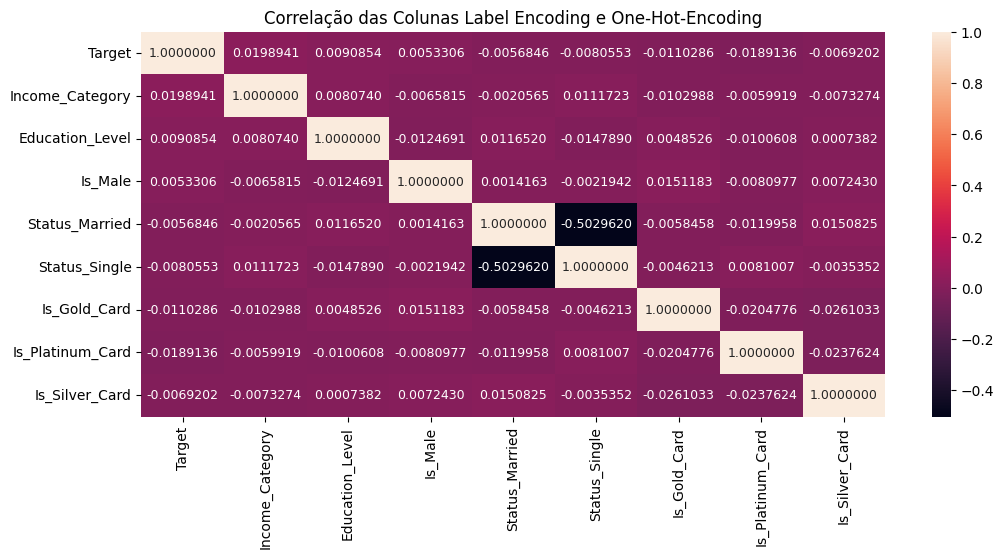

In [18]:
colunas_encoding = [
                    'Target', 'Income_Category', 'Education_Level',
                    'Is_Male', 'Status_Married', 'Status_Single', 
                    'Is_Gold_Card','Is_Platinum_Card', 'Is_Silver_Card'
                ]
                                        
df_encoding_correlations = df_base_credit[colunas_encoding].corr() 

plt.figure(figsize=(12, 5))

sns.heatmap(data=df_encoding_correlations, 
            annot=True, fmt=".7f", annot_kws={"size": 9})
plt.title("Correlação das Colunas Label Encoding e One-Hot-Encoding")
plt.show()

#### Análise de Correlação da coluna Target com as novas colunas criadas e as colunas relacionadas a elas


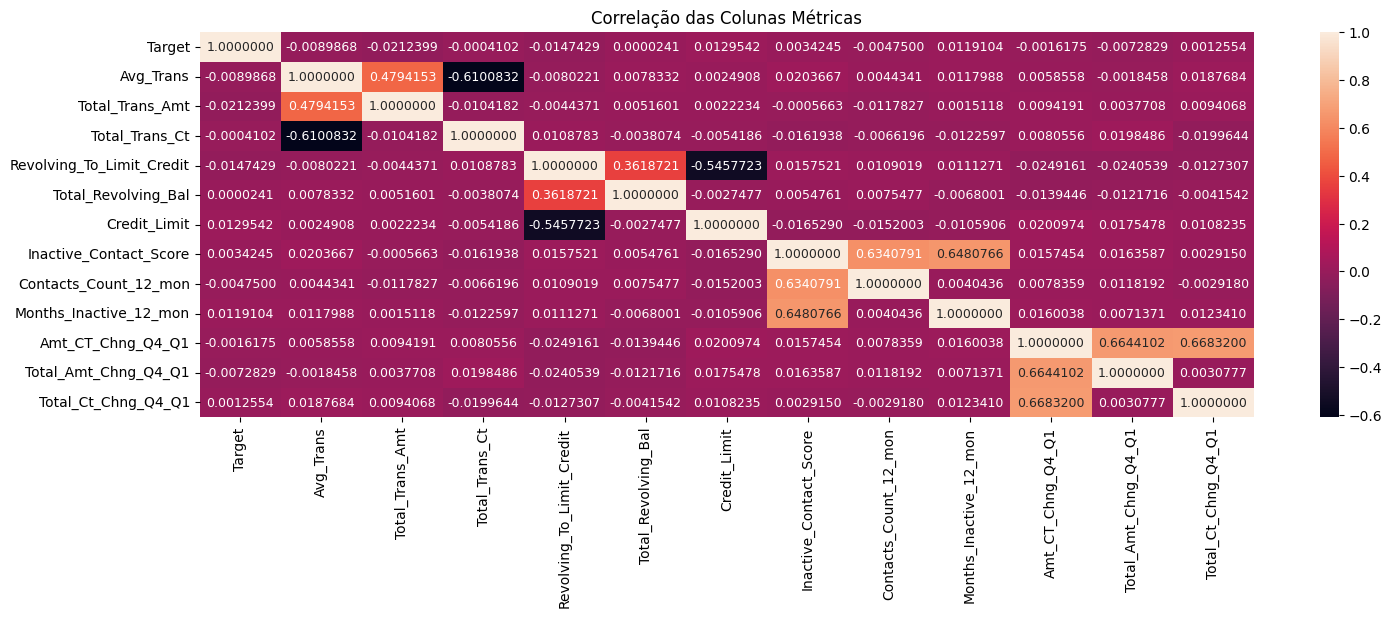

In [19]:
colunas_metricas = ['Target', 'Avg_Trans',
                    'Total_Trans_Amt', 'Total_Trans_Ct',

                    'Revolving_To_Limit_Credit',
                    'Total_Revolving_Bal', 'Credit_Limit',

                    'Inactive_Contact_Score',
                    'Contacts_Count_12_mon', 'Months_Inactive_12_mon',

                    'Amt_CT_Chng_Q4_Q1',
                    'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1'
                ]

df_correlation_columns = df_base_credit[colunas_metricas].corr()

plt.figure(figsize=(17, 5))

sns.heatmap(data=df_correlation_columns, 
            annot=True, fmt=".7f", annot_kws={"size": 9})
plt.title("Correlação das Colunas Métricas")
plt.show()

#### Avaliação das colunas restantes

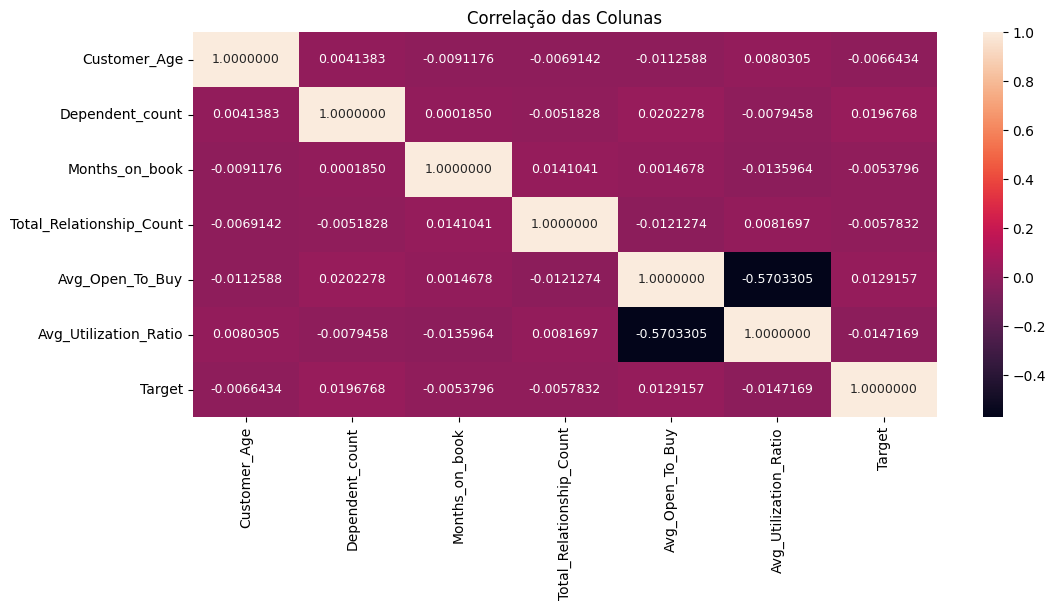

In [20]:
df_correlations = df_base_credit.drop(columns=[
                                        'CLIENTNUM', 'Attrition_Flag',
                                        'Income_Category', 'Education_Level', 
                                                                                
                                        'Is_Male', 
                                        'Status_Married', 'Status_Single', 
                                        'Is_Gold_Card','Is_Platinum_Card', 'Is_Silver_Card',
                                         
                                        'Avg_Trans',
                                        'Total_Trans_Amt', 'Total_Trans_Ct',

                                        'Revolving_To_Limit_Credit',
                                        'Total_Revolving_Bal', 'Credit_Limit',

                                        'Inactive_Contact_Score',
                                        'Contacts_Count_12_mon', 'Months_Inactive_12_mon',

                                        'Amt_CT_Chng_Q4_Q1',
                                        'Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1'  
                                    ]).corr() 

plt.figure(figsize=(12, 5))

sns.heatmap(data=df_correlations, 
            annot=True, fmt=".7f", annot_kws={"size": 9})
plt.title("Correlação das Colunas")
plt.show()

### Conclusões

* A coluna CLIENTNUM foi removida do conjunto de dados por se tratar de
  um identificador de cliente. Por não gerar poder preditivo, poderá 
  causar Overfitting ou ruído entre modelos

* Foi identificado uma forte Multicolinearidade entre as
  colunas Avg_Open_To_Buy e Credit_Limit (aproximadamente 0.99).
  Foi decidido remover o Avg_Open_To_Buy, pois o Credit_Limit apresenta
  uma relação linear mais consistente com a variável alvo

* A coluna Customer_Age apresenta correlação linear
  desprezível com o Attrition_Flag, além de demonstrar redundância entre si. Foi 
  decidido remover essa coluna para simplificar o modelo

* A coluna Total_Trans_Amt apresenta uma redundancia severa com a coluna 
  criada Avg_Trans

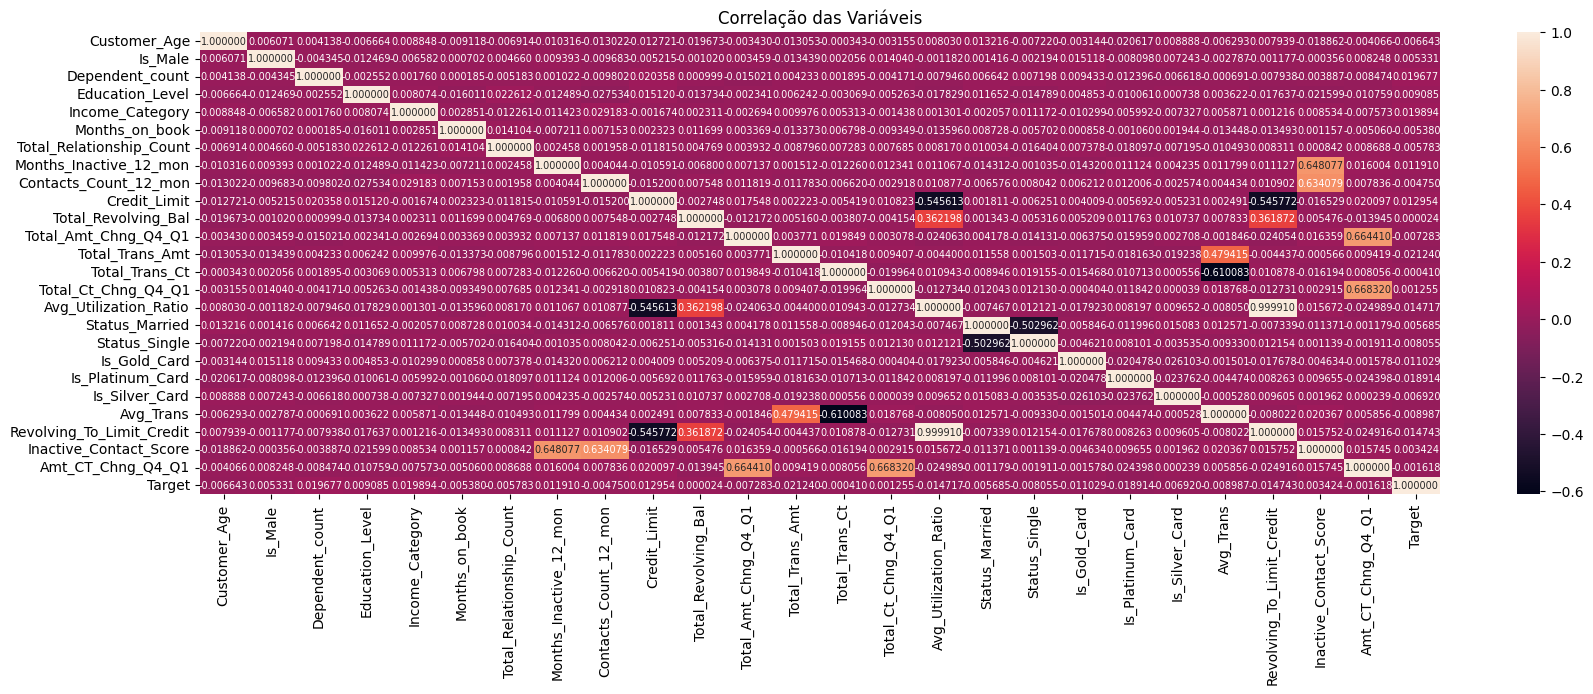

In [21]:
colunas_remover = [
                'CLIENTNUM', 'Attrition_Flag', 'Avg_Open_To_Buy', 
                #'Customer_Age','Total_Trans_Amt',

                #'Months_on_book', 'Dependent_count', 

               # 'Total_Ct_Chng_Q4_Q1',
               # 'Total_Relationship_Count',   
  
              #  'Is_Male', 
               # 'Status_Married', 'Status_Single',
               # 'Amt_CT_Chng_Q4_Q1',
               # 'Contacts_Count_12_mon'
              ]

df_credit_clean = df_base_credit.drop(columns=colunas_remover)

plt.figure(figsize=(20, 6))

sns.heatmap(data=df_credit_clean.corr(), 
            annot=True, fmt=".6f", annot_kws={"size": 7})
plt.title("Correlação das Variáveis")
plt.show()

### Definição das variáveis de treino e teste

In [22]:
X = df_credit_clean.drop(columns=['Target'], axis=1)
y = df_credit_clean['Target'].copy()

# 1) Será dividido os dados dos eixos x e y em 70% de treino e 30% de teste
# stratify -> variável alvo
# random_state -> trava o sorteio para ser sempre igual

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# 2) No caso de desbalanceamento de dados, poderá ser usado o scale_pos_weight para dar mais peso aos itens da classe minoritaria

scale_weight = len(Y_train[Y_train == 0])/len(Y_train[Y_train == 1])

print(f'Casos Classe 0: {len(Y_train[Y_train == 0])}')
print(f'Casos Classe 1: {len(Y_train[Y_train == 1])}')
print(f'Valor calculado para scale_pos_weight: {scale_weight}')


Casos Classe 0: 5923
Casos Classe 1: 1077
Valor calculado para scale_pos_weight: 5.499535747446611


# Modelo de Regressão Logística

In [23]:
# Deve ser aplicado o StandardScaler para que o Modelo de Regressão Logística
# consiga colocar todas as variáveis na mesma escala

scaler = StandardScaler()

X_train_scalled = scaler.fit_transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [24]:
# criação do modelo
logistic_regression = LogisticRegression(class_weight='balanced', random_state=42)

# treinamento do modelo
logistic_regression.fit(X_train_scalled, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [25]:
# Comparativo com os Limites do Logistic Regression

#prob_lr = logistic_regression.predict_proba(X_test_scalled)[:, 1]

#for lmt in np.arange(0.1, 1, 0.1):
    #print(f"Matriz de Confusão - Limite {lmt:.2f}")
    #print(confusion_matrix(Y_test, (prob_lr > lmt).astype("int") ), "\n")

In [26]:

pred_lr = logistic_regression.predict_proba(X_test_scalled)[:, 1] # .predict(X_test_scalled) (por padrão o limite da função predict é 0.5)

limite_ideal = gmean_max(logistic_regression, X_test_scalled, Y_test)

pred_proba_lr = (pred_lr > limite_ideal).astype("int")

print(f'Limite Ideal para Matriz de Confusão (Logistic Regression): {limite_ideal}\n')
print(f"Matriz de Confusão (Logistic Regression):\n{confusion_matrix(Y_test, pred_proba_lr)}\n")

print(f"Relatório (Logistic Regression):\n {
                classification_report(Y_test, pred_proba_lr, 
                                      target_names=['Permaneceu', 'Churn'], zero_division=0)
            }")

Melhor G-Means: 0.5144503566440004
Limite Ideal para Matriz de Confusão (Logistic Regression): 0.5027026353120538

Matriz de Confusão (Logistic Regression):
[[1421 1118]
 [ 244  217]]

Relatório (Logistic Regression):
               precision    recall  f1-score   support

  Permaneceu       0.85      0.56      0.68      2539
       Churn       0.16      0.47      0.24       461

    accuracy                           0.55      3000
   macro avg       0.51      0.52      0.46      3000
weighted avg       0.75      0.55      0.61      3000



# Modelo Random Florest

In [27]:
# criação do modelo
random_florest = RandomForestClassifier(
    
    class_weight='balanced', # rebalanceia o peso de cada árvore criada
    # balanced_subsample

    n_estimators=800, # quantidade de estimativas
    max_depth=5, # impede que os dados sejam decorados
    min_samples_leaf=10, # evita folhas com poucos clientes
    random_state=42,
    #n_jobs=1
) 

# treinar o modelo
random_florest.fit(X_train, Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [28]:
# Treinamento do Modelo Calibrado de RF

calibrated_rf = CalibratedClassifierCV(random_florest, method='sigmoid', cv=5)

calibrated_rf.fit(X_train, Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",800
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'


In [29]:
# Previsão do modelo
pred_rf = random_florest.predict_proba(X_test)[:, 1]
limite_ideal_rf = gmean_max(random_florest, X_test, Y_test)

pred_rf = (pred_rf > limite_ideal_rf).astype("int")

print(f'Limite Ideal (Random Florest): {limite_ideal_rf}')
print(f'Matriz de Confusão (Random Florest): {confusion_matrix(Y_test, pred_rf)}')
print(f"Relatório (Random Florest):\n {
                classification_report(
                    Y_test, pred_rf, target_names=['Permaneceu', 'Churn'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )
            }\n")



# Previsão do modelo calibrado
pred_rf_calibrated = calibrated_rf.predict_proba(X_test)[:, 1]
limite_ideal_calibrated_rf = gmean_max(calibrated_rf, X_test, Y_test)

pred_rf_calibrated = (pred_rf_calibrated > limite_ideal_calibrated_rf).astype("int")

print(f'Limite Ideal (Random Florest Calibrated): {limite_ideal_calibrated_rf}')
print(f'Matriz de Confusão (Random Florest Calibrated): {confusion_matrix(Y_test, pred_rf_calibrated)}')
print(f"Relatório (Random Florest Calibrated):\n {
                classification_report(
                    Y_test, pred_rf_calibrated, target_names=['Permaneceu', 'Churn'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )}")


Melhor G-Means: 0.5000292606683686
Limite Ideal (Random Florest): 0.48086129001716316
Matriz de Confusão (Random Florest): [[1117 1422]
 [ 200  261]]
Relatório (Random Florest):
               precision    recall  f1-score   support

  Permaneceu       0.85      0.44      0.58      2539
       Churn       0.16      0.57      0.24       461

    accuracy                           0.46      3000
   macro avg       0.50      0.50      0.41      3000
weighted avg       0.74      0.46      0.53      3000


Melhor G-Means: 0.5153480157347684
Limite Ideal (Random Florest Calibrated): 0.1540606428908831
Matriz de Confusão (Random Florest Calibrated): [[1413 1126]
 [ 242  219]]
Relatório (Random Florest Calibrated):
               precision    recall  f1-score   support

  Permaneceu       0.85      0.56      0.67      2539
       Churn       0.16      0.48      0.24       461

    accuracy                           0.54      3000
   macro avg       0.51      0.52      0.46      3000
weighted a

# Modelo XGBoost Classifier

In [30]:
# criação do modelo
xgboost_classifier = xgb.XGBClassifier(
            scale_pos_weight=scale_weight,  # Corrige a inversão penalizando o erro no Churn
            n_estimators=600,
            learning_rate=0.01,
            max_depth=4,
            reg_alpha=1, # Regularização L1 para suavizar os pesos
            reg_lambda=1, # Regularização L1 para suavizar os pesos
            eval_metric='auc',
            random_state=42
        ) 

# treinamento do modelo
xgboost_classifier.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [31]:
# treinar o modelo calibrado
xgb_calibrated = CalibratedClassifierCV(estimator=xgboost_classifier, cv=5, method='sigmoid')

xgb_calibrated.fit(X_train, Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[flo

In [32]:
# Previsão do modelo

#pred_xgboot = xgboost_classifier.predict(X_test)

pred_xgboost = xgboost_classifier.predict_proba(X_test)[:, 1]
limite_xgboost = gmean_max(xgboost_classifier, X_test, Y_test)

pred_xgboost = (pred_xgboost > limite_xgboost).astype("int") 

print(f'Limite Ideal (XGBoost Classifier): {limite_xgboost}\n')
print(f"Matriz de Confusão (XGBoost Classifier):\n{confusion_matrix(Y_test, pred_xgboost)}\n")

print(f"Relatório (XGBoost Classifier):\n {
                classification_report(
                    Y_test, pred_xgboost, target_names=['Permaneceu', 'Churn'],
                    zero_division=0
                )
            }\n")




# Previsão (XGBoost Calibrado)
pred_xgb_calibrated = xgb_calibrated.predict_proba(X_test)[:, 1]
limite_ideal_xgb_calibrated  = gmean_max(xgb_calibrated, X_test, Y_test)

pred_xgb_calibrated  = (pred_xgb_calibrated > limite_ideal_xgb_calibrated).astype("int") 

print(f'Limite Ideal (XGBoost Classifier Calibrated): {limite_ideal_xgb_calibrated}\n')
print(f"Matriz de Confusão (XGBoost Classifier Calibrated):\n{confusion_matrix(Y_test, pred_xgb_calibrated  )}\n")

print(f"Relatório (XGBoost Classifier Calibrated):\n {
                classification_report(
                    Y_test, pred_xgb_calibrated, target_names=['Permaneceu', 'Churn'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )
            }")

Melhor G-Means: 0.5016830157304251
Limite Ideal (XGBoost Classifier): 0.47729963064193726

Matriz de Confusão (XGBoost Classifier):
[[1333 1206]
 [ 241  220]]

Relatório (XGBoost Classifier):
               precision    recall  f1-score   support

  Permaneceu       0.85      0.53      0.65      2539
       Churn       0.15      0.48      0.23       461

    accuracy                           0.52      3000
   macro avg       0.50      0.50      0.44      3000
weighted avg       0.74      0.52      0.58      3000


Melhor G-Means: 0.5235714737653667
Limite Ideal (XGBoost Classifier Calibrated): 0.1536429761773032

Matriz de Confusão (XGBoost Classifier Calibrated):
[[1315 1224]
 [ 218  243]]

Relatório (XGBoost Classifier Calibrated):
               precision    recall  f1-score   support

  Permaneceu       0.86      0.52      0.65      2539
       Churn       0.17      0.53      0.25       461

    accuracy                           0.52      3000
   macro avg       0.51      0.52   

# Modelo LGBM CLASSIFIER

para tentar gerar resultados mais precisos com dados tabulares balanceados foi
apresentado o modelo LGBM Classifier

In [33]:
# ao utilizar a opção 'is_unbalance', deve saber quem é a menor classe para dar mais peso

# OBS: o 'is_unbalance' não pode ser executado quando tiver o scale_pos_weight


lgbm_classifier = LGBMClassifier(

                        objective='binary', # Força classifficação binaria estruturada 
                        metric='auc', # Força o modelo a otimizar a AUC interna do modelo 

                        #class_weight='balanced', # Dá um peso maior para a classe 1

                        # parametros para evitar overfitting (fazer o modelo espalhar probabilidades)
                        scale_pos_weight=scale_weight, # multiplica o peso da classe 1 (Churn) pela proporcao
                        #learning_rate=0.03,
                        #max_depth=-1, #(-1) -> sem limite rigido de profundidade
                       # num_leaves=15, # limita o numero de nós/folhas
                        random_state=42,
                       # min_child_samples=50, # numero mínimo de clientes necessários para criar uma bifurcação (divisão em dois ramos)            
                        verbose=-1
                        #n_estimators=300,
                    )

lgbm_classifier.fit(X_train, Y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
# treinar o modelo calibrado
lgbm_callibred = CalibratedClassifierCV(estimator=lgbm_classifier, cv=5, method='sigmoid')

lgbm_callibred.fit(X_train, Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","LGBMClassifie...1, verbose=-1)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000


In [35]:
# Previsão do modelo

pred_lgbm_classifier = lgbm_classifier.predict_proba(X_test)[:, 1]
limite_lgbm_classifier = gmean_max(lgbm_classifier, X_test, Y_test)

pred_lgbm = (pred_lgbm_classifier > limite_lgbm_classifier).astype("int") 

print(f'Limite Ideal (LGBM Classifier): {limite_lgbm_classifier}')
print(f"Matriz de Confusão (LGBM Classifier):\n{confusion_matrix(Y_test, pred_lgbm)}\n")

print(f"Relatório (LGBM Classifier):\n {
                classification_report(
                    Y_test, pred_lgbm, target_names=['Permaneceu', 'Churn'],
                    zero_division=0
                )
            }\n")


# Previsão (LGBM Classifier Calibrado)
pred_lgbm_calibrated= lgbm_callibred.predict_proba(X_test)[:, 1]
limite_ideal_lgbm_calibrated = gmean_max(lgbm_callibred, X_test, Y_test)

pred_lgbm_calibrated  = (pred_lgbm_calibrated > limite_ideal_lgbm_calibrated).astype("int") 

print(f'Limite Ideal (LGBM Classifier Calibrated): {limite_ideal_lgbm_calibrated}\n')
print(f"Matriz de Confusão (LGBM Classifier Calibrated):\n{confusion_matrix(Y_test, pred_lgbm_calibrated  )}\n")

print(f"Relatório (LGBM Classifier Callibred):\n {
                classification_report(
                    Y_test, pred_lgbm_calibrated, target_names=['Permaneceu', 'Churn'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )
            }")

Melhor G-Means: 0.49122593536371045
Limite Ideal (LGBM Classifier): 0.356849456925652
Matriz de Confusão (LGBM Classifier):
[[1228 1311]
 [ 232  229]]

Relatório (LGBM Classifier):
               precision    recall  f1-score   support

  Permaneceu       0.84      0.48      0.61      2539
       Churn       0.15      0.50      0.23       461

    accuracy                           0.49      3000
   macro avg       0.49      0.49      0.42      3000
weighted avg       0.73      0.49      0.55      3000


Melhor G-Means: 0.5161928083820122
Limite Ideal (LGBM Classifier Calibrated): 0.15391350150104605

Matriz de Confusão (LGBM Classifier Calibrated):
[[1356 1183]
 [ 232  229]]

Relatório (LGBM Classifier Callibred):
               precision    recall  f1-score   support

  Permaneceu       0.85      0.53      0.66      2539
       Churn       0.16      0.50      0.24       461

    accuracy                           0.53      3000
   macro avg       0.51      0.52      0.45      3000
we

# Modelo CatBoostClassifier

In [36]:
catboost_classifier = CatBoostClassifier(
                                        iterations=600, 
                                       # depth=6, 
                                        learning_rate=0.05, 
                                        random_state=42,
                                        #l2_leaf_reg=10, # Regularização L2 para ajudar a generalizar as variaveis codificaveis
                                        verbose=False, # mostra o progresso
                                        eval_metric='AUC', # otimiza a curva do coeficiente de gini
                                        #scale_pos_weight=scale_weight
                                        auto_class_weights='Balanced' # correção de desbalanceamento
                                    )

catboost_classifier.fit(X_train, Y_train)

CatBoostClassifier(auto_class_weights='Balanced', eval_metric='AUC', iterations=600, learning_rate=0.05, random_state=42, verbose=False)

In [37]:
# treinar o modelo calibrado
catboost_calibrated = CalibratedClassifierCV(estimator=catboost_classifier, cv=5, method='sigmoid')

catboost_calibrated.fit(X_train, Y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",CatBoostClass...verbose=False)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'


In [38]:
# Previsão do Modelo

pred_catboost_classifier = catboost_classifier.predict_proba(X_test)[:, 1] 

limite_catboost_classifier = gmean_max(catboost_classifier, X_test, Y_test)

pred_catboost_classifier = (pred_catboost_classifier > limite_catboost_classifier).astype("int") 

print(f'Limite Ideal (CatBoost Classifier): {limite_catboost_classifier}\n')
print(f"Matriz de Confusão (CatBoost Classifier):\n{confusion_matrix(Y_test, pred_catboost_classifier)}\n")

print(f"Relatório (CatBoost Classifier):\n {
                classification_report(
                    Y_test, pred_catboost_classifier, target_names=['Permaneceu', 'Churn'],
                    zero_division=0
                )
            }")


# Previsão (Catboost Classifier Calibrado)
pred_catboost_calibrated = catboost_calibrated.predict_proba(X_test)[:, 1]
limite_ideal_catboost_calibrated= gmean_max(catboost_calibrated, X_test, Y_test)

pred_catboost_calibrated  = (pred_catboost_calibrated > limite_ideal_catboost_calibrated).astype("int") 

print(f'Limite Ideal (CatBoost Classifier Calibrated): {limite_ideal_catboost_calibrated}\n')
print(f"Matriz de Confusão (CatBoost Classifier Calibrated):\n{confusion_matrix(Y_test, pred_catboost_calibrated  )}\n")

print(f"Relatório (CatBoost Classifier Calibrated):\n {
                classification_report(
                    Y_test, pred_catboost_calibrated, target_names=['Permaneceu', 'Churn'],
                    zero_division=0 # define o valor a retornar caso tenha alguma divisão por 0
                )
            }")

Melhor G-Means: 0.5001795950605852
Limite Ideal (CatBoost Classifier): 0.34039304182520685

Matriz de Confusão (CatBoost Classifier):
[[1362 1177]
 [ 247  214]]

Relatório (CatBoost Classifier):
               precision    recall  f1-score   support

  Permaneceu       0.85      0.54      0.66      2539
       Churn       0.15      0.46      0.23       461

    accuracy                           0.53      3000
   macro avg       0.50      0.50      0.44      3000
weighted avg       0.74      0.53      0.59      3000

Melhor G-Means: 0.5250697475388065
Limite Ideal (CatBoost Classifier Calibrated): 0.15405135423015578

Matriz de Confusão (CatBoost Classifier Calibrated):
[[1339 1200]
 [ 221  240]]

Relatório (CatBoost Classifier Calibrated):
               precision    recall  f1-score   support

  Permaneceu       0.86      0.53      0.65      2539
       Churn       0.17      0.52      0.25       461

    accuracy                           0.53      3000
   macro avg       0.51      0

# Teste AUC SCORE e Coeficiente de Gini

## Coeficiente de Gini
caso o coeficiente esteja menor que 0 quer dizer que o modelo está invertendo previsões
e for 0 o modelo é aleatiro, se for 1 o modelo é perfeito

In [44]:
# (Caso o AUC for menor que 0.5, quer dizer que o coefiiente de gini terá um desempenho no pior caso)

modelos = {
            "LR": logistic_regression, # Modelo Linear
            "RF": random_florest, "RF_Calibrated": calibrated_rf, 
            "XGB": xgboost_classifier, "XGB Callibrated": xgb_calibrated,
            "LGBM": lgbm_classifier, "LGBM Callibrated": lgbm_callibred,
            "CATBOOST": catboost_classifier, "CATBOOST Callibrated": catboost_calibrated,
        }

auc = ''
gini = '' 
df_comparativo = []

for x in modelos:
    if x == 'LR':
        auc, gini = gini_coeficient(modelos[x], X_test_scalled, Y_test)
    else:
        auc, gini = gini_coeficient(modelos[x], X_test, Y_test)

    print(x, ";", auc, ";", gini)
    df_comparativo.append([x, auc, gini])


pd.DataFrame(df_comparativo, columns=['Modelo', 'Area Under Curve', 'Gini Coeficient'])

LR ; 0.5126738711245566 ; 0.025347742249113292
RF ; 0.4948777380884236 ; -0.010244523823152774
RF_Calibrated ; 0.5061380853479643 ; 0.012276170695928679
XGB ; 0.4917025422925145 ; -0.016594915414971045
XGB Callibrated ; 0.5146491308259268 ; 0.029298261651853563
LGBM ; 0.48010857093548875 ; -0.03978285812902249
LGBM Callibrated ; 0.5117451914985233 ; 0.023490382997046533
CATBOOST ; 0.49516907180735414 ; -0.009661856385291712
CATBOOST Callibrated ; 0.519376255362121 ; 0.038752510724241906


,Modelo,Area Under Curve,Gini Coeficient
0,LR,0.51,2.53e-02
1,RF,0.49,-1.02e-02
2,RF_Calibrated,0.51,1.23e-02
3,XGB,0.49,-1.66e-02
4,XGB Callibrated,0.51,2.93e-02
5,LGBM,0.48,-3.98e-02
6,LGBM Callibrated,0.51,2.35e-02
7,CATBOOST,0.50,-9.66e-03
8,CATBOOST Callibrated,0.52,3.88e-02


# Avaliação da Precisão das Colunas

In [ ]:
# Precisão: Entre os casos que o modelo previu quantos estão corretos

rf_calibrated_importances = np.mean(
    [orig_model.estimator.feature_importances_  
     for orig_model in calibrated_rf.calibrated_classifiers_]
, axis=0)

xgb_calibrated_importances = np.mean(
    [orig_model.estimator.feature_importances_  
     for orig_model in xgb_calibrated.calibrated_classifiers_]
, axis=0)

lgm_calibrated_importances = np.mean(
    [ orig_model.estimator.feature_importances_  
      for orig_model in lgbm_callibred.calibrated_classifiers_
    ], axis=0)

catboost_calibrated_importances = np.mean(
    [orig_model.estimator.feature_importances_  
     for orig_model in catboost_calibrated.calibrated_classifiers_
    ], axis=0)


df_importancia = pd.DataFrame({
    'Importância (Logistic Regression)': logistic_regression.coef_[0] ,

    'Importância (Random Florest)': random_florest.feature_importances_,
    'Importância (Random Florest Calibrated)': rf_calibrated_importances,

    'Importância (XGBoost Classifier)': xgboost_classifier.feature_importances_,
    'Importância (XGBoost Calibrated)': xgb_calibrated_importances,

    'Importância (LGBM Classifier)': lgbm_classifier.feature_importances_,
    'Importância (LGBM Calibrated)': lgm_calibrated_importances,

    'Importância (CatBoost Classifier)': catboost_classifier.feature_importances_,
    'Importância (CatBoost Calibrated)': catboost_calibrated_importances

    }, index=X_train.columns
).reset_index(names='Coluna')

df_importancia

,Coluna,Importância (Logistic Regression),Importância (Random Florest),Importância (RandomFlorest Calibrated),Importância (XGBoost Classifier),Importância (XGBoost Calibrated),Importância (LGBM Classifier),Importância (LGBM Calibrated),Importância (CatBoost Classifier),Importância (CatBoost Calibrated)
0,Customer_Age,-1.11e-02,4.41e-02,4.82e-02,0.03,0.04,191,194.6,5.60,6.07
1,Is_Male,2.35e-02,6.03e-03,6.77e-03,0.03,0.04,23,25.6,0.92,0.96
2,Dependent_count,7.96e-02,3.73e-02,3.76e-02,0.04,0.04,83,78.4,3.96,4.00
3,Education_Level,5.54e-02,2.83e-02,2.85e-02,0.04,0.04,88,84.8,3.95,3.60
4,Income_Category,7.41e-02,3.42e-02,3.45e-02,0.04,0.05,73,78.2,3.80,4.24
5,Months_on_book,1.29e-03,4.38e-02,4.51e-02,0.04,0.04,190,188.4,5.97,5.78
6,Total_Relationship_Count,-4.19e-02,2.44e-02,2.35e-02,0.04,0.04,79,74.2,3.30,3.76
7,Months_Inactive_12_mon,-2.50e-03,1.94e-02,2.19e-02,0.04,0.04,65,78.8,3.76,3.43
8,Contacts_Count_12_mon,-4.94e-02,2.74e-02,2.65e-02,0.04,0.04,88,86.4,3.74,3.93
9,Credit_Limit,1.88e-02,8.03e-02,8.27e-02,0.04,0.04,248,236.2,7.56,7.04
